# <span style="color: purple;">Lesson 7 - Decision Trees</span>

**Developers:** Wei &nbsp;|&nbsp; **Reviewers:**

---

## <span style="color: purple;">🎯 Learning Objectives</span>

By the end of this lesson, you will have:

- Trained a decision tree model that makes predictions by asking yes/no questions
- Visualised the tree to see exactly how it makes decisions
- Discovered what happens when a tree is too deep or too shallow
- Compared trees of different depths to find the best one

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [1]:
# ─────────────────────────────────────────────────────────────
# Setup cell — run this first, then you can ignore it
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🧩 What is a Decision Tree?</span>

Think about how you might identify an animal. You could ask a series of yes/no questions:

- Does it have fur? → **Yes** → Does it bark? → **Yes** → It's a **dog**!
- Does it have fur? → **Yes** → Does it bark? → **No** → It's a **cat**!
- Does it have fur? → **No** → It's a **fish**!

That's exactly how a decision tree works. It learns which questions to ask about the data, and in what order, to sort things into groups.

<div class="alert alert-success">

**Decision Tree** — A model that makes predictions by asking a series of yes/no questions about the data, splitting it into smaller groups at each step until it reaches an answer.

</div>

The big advantage of a decision tree is that you can **see** exactly how it makes decisions — unlike the models we've used so far, which are more of a black box.

---

## <span style="color: purple;">Step 1 — Load the data</span>

We'll use the same iris flower dataset from Lesson 2. As before, we split it into training and testing sets.

<div class="alert alert-info">

**Run the next cell** to load the data and split it.

</div>

In [2]:
# Load the iris dataset and split it
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

print(f"Training flowers: {len(X_train)}")
print(f"Testing flowers:  {len(X_test)}")
print("✓ Data loaded")

Training flowers: 120
Testing flowers:  30
✓ Data loaded


---

## <span style="color: purple;">Step 2 — Train a decision tree</span>

Now we train a decision tree on the training flowers. We set `max_depth=2`, which means the tree can ask at most **2 questions** before making a prediction.

<div class="alert alert-success">

**Depth** — The maximum number of questions the tree is allowed to ask. A depth of 2 means two yes/no questions before reaching an answer.

</div>

<div class="alert alert-info">

**Run the next cell** to train the tree and see its accuracy.

</div>

In [3]:
# Train a decision tree with depth 2
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

# Test it on the 30 held-back flowers
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100

print(f"Tree depth: 2")
print(f"Test accuracy: {accuracy:.1f}%")
print("✓ Tree trained")

Tree depth: 2
Test accuracy: 96.7%
✓ Tree trained


<div class="alert alert-info">

### 👀 What just happened?

With just **2 questions**, the tree can already classify most flowers correctly. But how does it decide which questions to ask? Let's look inside the tree.

</div>

---

## <span style="color: purple;">Step 3 — Look inside the tree</span>

This is the best part about decision trees: you can actually draw them out and see every decision the model makes. Each box is called a **node**.

<div class="alert alert-success">

**Node** — A single decision point in the tree. Each node asks one yes/no question about a measurement, splitting the data into two groups.

</div>

<div class="alert alert-info">

**Run the next cell** to draw the tree.

</div>

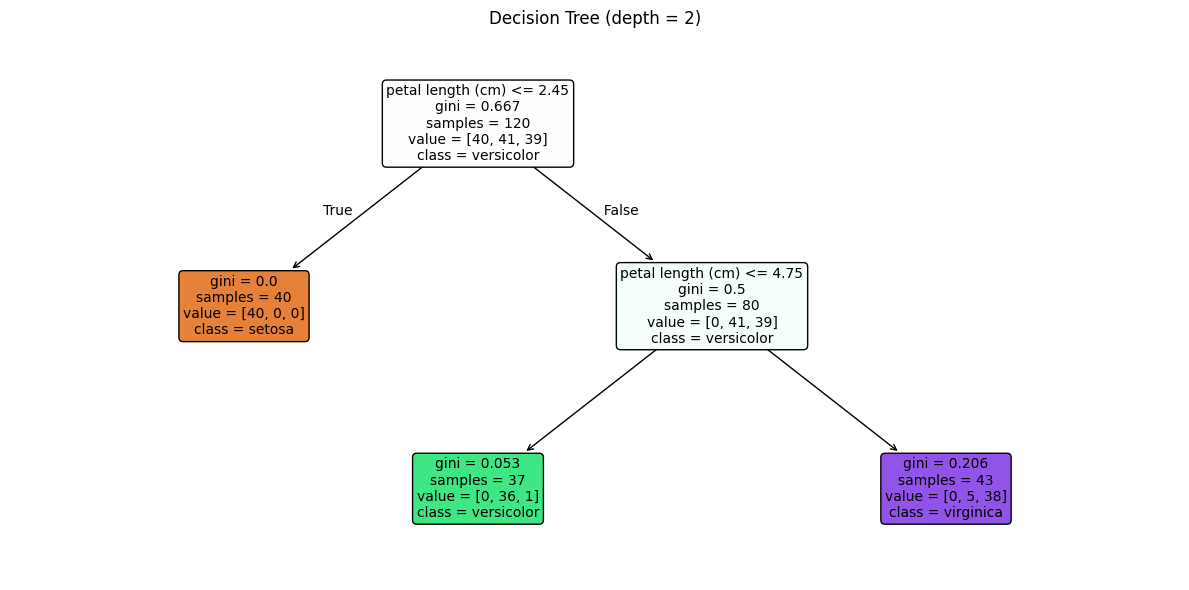

✓ Tree plotted


In [4]:
# Draw the decision tree
plt.figure(figsize=(12, 6))
plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (depth = 2)")
plt.tight_layout()
plt.show()
print("✓ Tree plotted")

<div class="alert alert-info">

### 👀 How to read the tree

- **Start at the top.** The first box asks a yes/no question about one of the flower measurements.
- **Go left for Yes**, right for No.
- **The colour** shows which species the tree would predict at that point. The darker the colour, the more confident it is.
- **`samples`** tells you how many training flowers reached that box.
- **`class`** is the species the tree would predict if it stopped here.

Try following a path from top to bottom — you're tracing the exact logic the model uses to classify a flower.

</div>

---

## <span style="color: purple;">Step 4 — What happens when you change the depth?</span>

A deeper tree can ask more questions, which means it can learn more detailed rules. But is deeper always better?

Let's train trees with depths 1 through 10 and compare how they perform on **training data** vs **test data**.

<div class="alert alert-info">

**Run the next cell** to compare different depths.

</div>

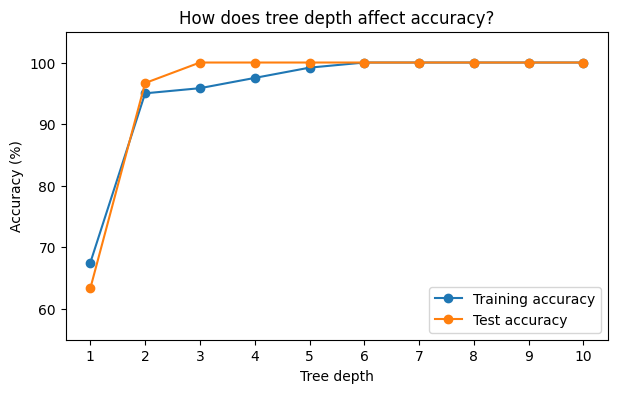

✓ Comparison plotted


In [5]:
# Compare trees of different depths
depths = range(1, 11)
train_scores = []
test_scores = []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, t.predict(X_train)) * 100)
    test_scores.append(accuracy_score(y_test, t.predict(X_test)) * 100)

# Plot the results
plt.figure(figsize=(7, 4))
plt.plot(depths, train_scores, "o-", label="Training accuracy")
plt.plot(depths, test_scores, "o-", label="Test accuracy")
plt.xlabel("Tree depth")
plt.ylabel("Accuracy (%)")
plt.title("How does tree depth affect accuracy?")
plt.xticks(range(1, 11))
plt.ylim(55, 105)
plt.legend()
plt.show()
print("✓ Comparison plotted")

<div class="alert alert-info">

### 👀 What's going on?

- **Training accuracy** keeps climbing as the tree gets deeper — eventually reaching 100%.
- **Test accuracy** improves quickly but then **stops improving**, even as the tree grows bigger.

This should look familiar from Lesson 6 — it's overfitting. The tree is memorising the training data without actually getting better at predicting new flowers. The iris dataset is very clean so the effect is mild here, but on messier real-world data a tree that's too deep will actually get **worse** on test data.

</div>

---

## <span style="color: purple;">Step 5 — Simple vs complex tree</span>

One of the best things about decision trees is that you can read them. But that only works if the tree is small enough. Let's compare a depth-2 tree with a depth-10 tree side by side.

<div class="alert alert-info">

**Run the next cell** to draw both trees.

</div>

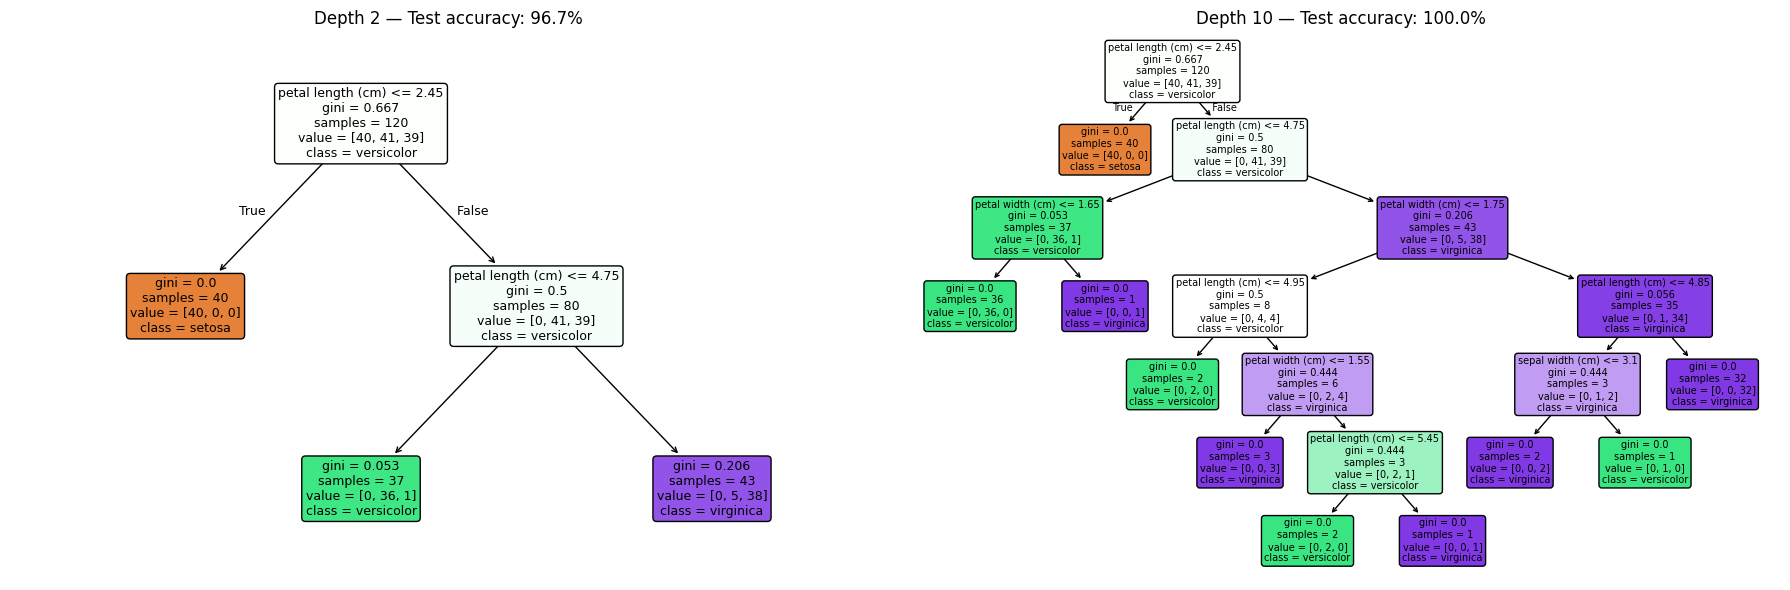

✓ Both trees plotted


In [6]:
# Compare a shallow tree vs a deep tree
shallow = DecisionTreeClassifier(max_depth=2, random_state=42)
shallow.fit(X_train, y_train)

deep = DecisionTreeClassifier(max_depth=10, random_state=42)
deep.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Shallow tree
plot_tree(shallow, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title(f"Depth 2 — Test accuracy: {accuracy_score(y_test, shallow.predict(X_test)) * 100:.1f}%")

# Deep tree
plot_tree(deep, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=7, ax=axes[1])
axes[1].set_title(f"Depth 10 — Test accuracy: {accuracy_score(y_test, deep.predict(X_test)) * 100:.1f}%")

plt.tight_layout()
plt.show()
print("✓ Both trees plotted")

<div class="alert alert-info">

### 👀 Compare the two trees

- The **shallow tree** (left) is simple — you can follow every decision and understand why it picked a species. This is what makes decision trees useful in practice.
- The **deep tree** (right) is a mess — far too complicated to interpret, and it doesn't even do better on the test data. This is overfitting in action: more complexity for no benefit.

A good model finds the balance: deep enough to learn the real patterns, but simple enough that you can still understand and trust it.

</div>

---

## <span style="color: purple;">🧠 What did we just do?</span>

We trained a decision tree — a model that makes predictions by asking a series of yes/no questions. We drew the tree to see exactly how it splits the data, and we saw that the depth controls how many questions it can ask. Too shallow and it can't learn much; too deep and it starts memorising the training data.

Unlike the models we've used before, decision trees let you look inside and understand every single decision. That makes them great when you need to explain **why** a model made a prediction.

---

### Key words

| Word | What it means |
|------|--------------:|
| **Decision Tree** | A model that predicts by asking a chain of yes/no questions |
| **Depth** | The maximum number of questions the tree can ask |
| **Node** | A single decision point (question) in the tree |

---

## <span style="color: purple;">🔧 Your turn!</span>

**Change `max_depth` below to find the depth that gives the best test accuracy. Try values between 1 and 10.**

Depth 3 → Training: 95.8%  |  Test: 100.0%


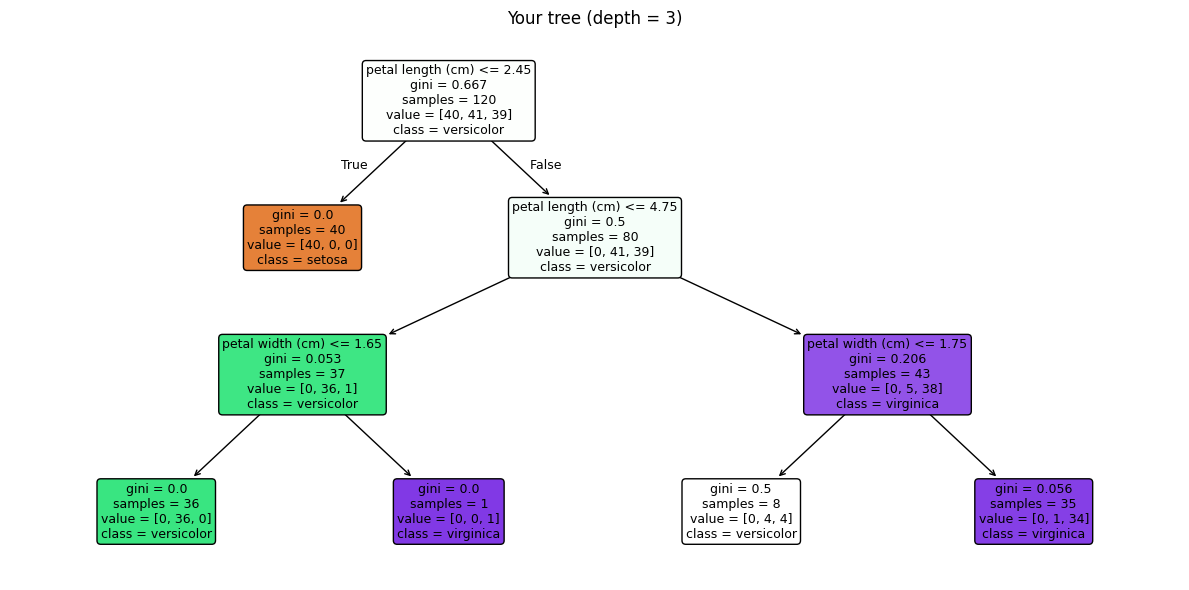

✓ Your tree plotted


In [7]:
# ▼▼▼▼▼▼▼▼▼▼▼▼▼▼  CHANGE THIS  ▼▼▼▼▼▼▼▼▼▼▼▼▼▼
max_depth = 3   # ← try values from 1 to 10
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲  CHANGE THIS  ▲▲▲▲▲▲▲▲▲▲▲▲▲▲

my_tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
my_tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, my_tree.predict(X_train)) * 100
test_acc = accuracy_score(y_test, my_tree.predict(X_test)) * 100

print(f"Depth {max_depth} → Training: {train_acc:.1f}%  |  Test: {test_acc:.1f}%")

plt.figure(figsize=(12, 6))
plot_tree(my_tree, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title(f"Your tree (depth = {max_depth})")
plt.tight_layout()
plt.show()
print("✓ Your tree plotted")

---

## <span style="color: purple;">🧪 Quick Quiz</span>

Test yourself on what you just learned. Run the code cell, select your answer for each question, then click **Check answers**.

In [8]:
from quiz import run_b07_quiz
run_b07_quiz()